# Analysis of simulated trajectorories

In [116]:
cd ~/work/tutorials/sources/OpenDrift/openberg_custom_juliette 

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette


In [117]:
# import pandas as pd
# import xarray as xr
# import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import glob
from src.utils import *
from src.utils2 import *

In [118]:
# Read and subset tracker data
obs_3day = read_tracker('./input/Osker-X2.csv')['3D']
obs = read_tracker('./input/Osker-X2.csv')['full']

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette/src/utils2.py:109: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette/src/utils2.py:109: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


In [119]:
# def colour_finder(sim_in,by='reader_'):
#     #pick colormap
#     cmap = plt.get_cmap('tab20')  # or 'viridis', 'plasma', etc.
#     colors = cmap(np.linspace(0, 1, 20))#20 colors
#     if by=='reader_x_sea_water_velocity': 
#         val = sim_in.reader_x_sea_water_velocity
#     return col_dict

In [120]:
# --- Which simulation data for plot? ---
note = "False" #'current_wind_nextsim_wave'
file_contain_all = ['waverys',]
file_contain_any = ['_']
file_notcontain = ['topaz4','glorys','slope','era5','almost','nextsim','wi']
file_l = glob.glob("./results/*.nc")#['./results/juliette_topaz6_topaz4_windglophynrt.nc',]
file_l = [f for f in file_l if all(ff in f for ff in file_contain_all)] #filtering for required keywords
file_l = [f for f in file_l if any(ff in f for ff in file_contain_any)] #filtering for required keywords
file_l = [f for f in file_l if all(ff not in f for ff in file_notcontain)] #filtering for neglected keywords
file_l

['./results/juliette_waverys.nc', './results/juliette_waverys_old.nc']

In [121]:
# --- Open all simulation results in one dataset ---
with xr.open_mfdataset(
    file_l,
    combine="nested",
    concat_dim="run",
    parallel=True,
    engine="netcdf4",
    # chunks={'time': 10}
) as simall: 
    simall = simall.assign_coords(run=file_l)  # or any list of labels

In [139]:
# # --- find trajectories
# # by seeding length
# seedinglengths = np.nanmax(simall.length[0,:,:],axis=1)
# seedinglengths_unq = np.unique(seedinglengths)
# print(seedinglengths_unq)
# seedinglengths_dict = {v: np.where(seedinglengths == v)[0].tolist() for v in seedinglengths_unq}
# trajs = np.array([seedinglengths_dict[sl] for sl in seedinglengths_unq[2:]]).flatten()

# #by time
# # trajs = False #np.arange(60,70,10)
# print(trajs, simall.sel(trajectory=trajs).time[np.array([0,-1])].values, np.unique(seedinglengths[trajs]))
# traj = False
# # note = 'wave_only_o300length'

0 ./results/juliette_waverys.nc [0.12156863 0.46666667 0.70588235 1.        ]
1 ./results/juliette_waverys_old.nc [1.         0.49803922 0.05490196 1.        ]


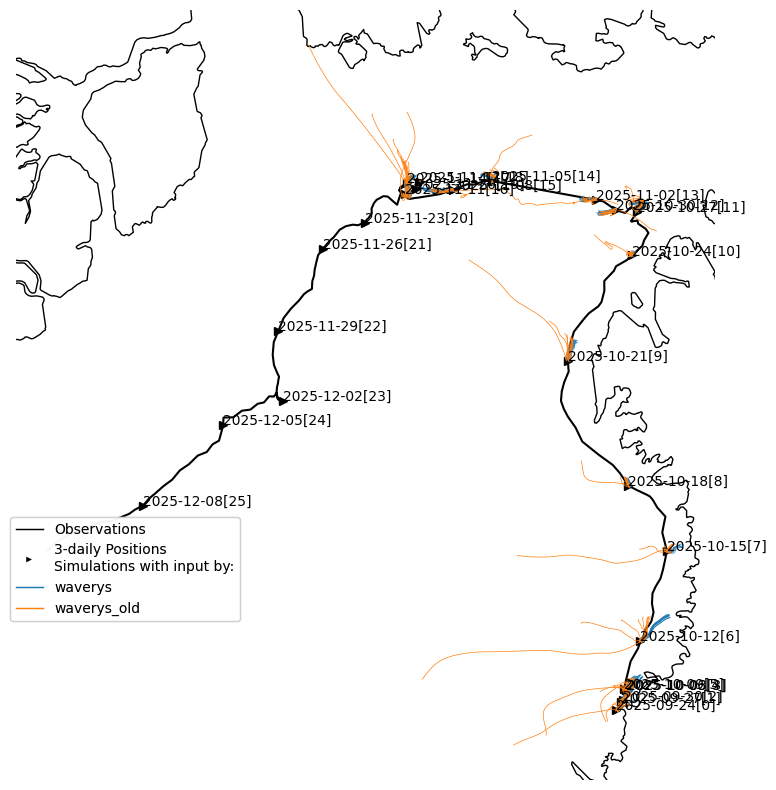

In [138]:
# Map plot comparing simulations with different input

#def
note = wave_only_oldnew
#by = inputdataidx
cmap = plt.get_cmap('tab20')  # or 'viridis', 'plasma', etc.
col = cmap(np.linspace(0, 1, 20))[::2]#20 colors

#Figure
fig,ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.NorthPolarStereo()})#central_longitude=20})
ax.coastlines(resolution='10m')
trans = ccrs.PlateCarree()
#ax.set_extent((-42.5, -11, 65, 78))

# plot obs
ax.plot(obs_3day['lon'],obs_3day['lat'],'>',transform=trans,color='k')
ax.plot(obs['lon'],obs['lat'],transform=trans,color='k',label='Observation')
# for d in range(obs_3day['time'].size):
for d in range(obs_3day.time.size):
    ax.text(obs_3day['lon'][d],obs_3day['lat'][d],obs_3day['time'][d].values.astype('datetime64[D]').astype(str)+'[%s]'%d,transform=trans,color='k')

# plot sim
for inputdataidx, inputdata in enumerate(simall.run.values):
    print(inputdataidx, inputdata, col[inputdataidx])
    for traj in simall.trajectory:# trajs if traj else simall.trajectory:
        ax.plot(simall.lon.sel(run=inputdata,trajectory=traj).dropna(dim="time"),simall.lat.sel(run=inputdata,trajectory=traj).dropna(dim="time"),
        color=col[inputdataidx],
                linewidth=0.5,
        transform=trans)
    # ax.plot(simall.lon.sel(run=inputdata),simall.lat.sel(run=inputdata),
    #         color=col[inputdataidx],linewidth=0.5,
    #         transform=trans)
    # dssim = xr.open_dataset(inputdata)
    # for traj in dssim.trajectory: #goes trhough trajectories with different coefficients, size, time and position #p.arange(0,dssim.trajectory[-1],10)
    #     ax.plot(dssim.lon[traj].dropna(dim="time"),dssim.lat[traj].dropna(dim="time"),
    #             color=col[inputdataidx],linewidth=0.5,
    #             transform=trans)
#legend
legend_elements = [Line2D([0], [0],linestyle='-', color='k', lw=1,label='Observations'),
                  Line2D([0], [0],linestyle='-', color='w',marker='>',markerfacecolor='k', lw=1,label='3-daily Positions \nSimulations with input by:')]
legend_elements = legend_elements+[Line2D([0], [0],linestyle='-', color=col[inputdataidx2], lw=1,label=inputdata2[19:-3]) for inputdataidx2,inputdata2 in enumerate(simall.run.values)]
leg = fig.legend(handles=legend_elements,bbox_to_anchor=(0.15, 0.38),loc='upper left')#fontsize=fs,ncol=len(legend_elements0+legend_elements2),                  columnspacing=0.6,labelspacing=0.3,loc='center',bbox_to_anchor=bbox_dict[kw][0])
plt.axis('off')
fig.add_artist(leg)
if note!=False: plt.savefig('./results/analysis_map_%s.png'%note,dpi=200,transparent=True,bbox_inches='tight')
plt.show()



In [137]:
np.sum(simall.sea_surface_height[0]>0.0)



<xarray.DataArray 'sea_surface_height' ()> Size: 8B
dask.array<sum-aggregate, shape=(), dtype=int64, chunksize=(), chunktype=numpy.ndarray>
Coordinates:
    run      <U33 132B './results/juliette_waverys.nc'
Attributes:
    minval:   0.0
    maxval:   0.0

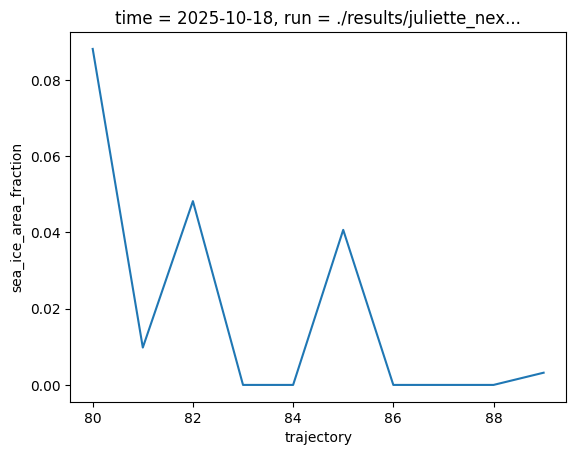

In [19]:
# --Check for variables from one "seeding round"
# simall.length[0,np.arange(60,70),:].dropna(dim='time').shape 

# --Check for variables at datetime
simall_t1 = simall.sel(time=datetime(2025,10,18,0), method="nearest") 

simall_t1_nan = simall_t1.dropna(
    dim="trajectory",
    # subset=["sea_surface_wave_from_direction"],
    subset=["length"],
    how="any" )
# print(simall_t1_nan.run) #which runs
#print (simall_t1_nan.trajectory) #which trajectory numbers
# simall_t1_nan.sea_surface_wave_from_direction.values
# simall_t1_nan.sea_surface_wave_significant_height.values
# simall_t1_nan.sea_surface_wave_stokes_drift_x_velocity.plot()
# simall_t1_nan.x_sea_water_velocity.values
simall_t1_nan.sea_ice_area_fraction.plot()

# simall_t1_nan.draft.values#[:,0].values


In [6]:
# --- open one result ---
sim = xr.open_dataset('./results/juliette_nextsimanfc_topaz5_windglophynrt.nc')
# np.sum(np.isnan(sim.x_sea_water_velocity))/sim.x_sea_water_velocity.size
# sim_t1 = sim.sel(time=datetime(2025,10,21,0), method="nearest") 
# sim_t1.sea_surface_wave_from_direction.plot()
# sim.x_sea_water_velocity.plot()
sim.attrs

{'Conventions': 'CF-1.11, ACDD-1.3',
 'standard_name_vocabulary': 'CF Standard Name Table v85',
 'featureType': 'trajectory',
 'title': 'OpenDrift trajectory simulation',
 'summary': 'Output from simulation with OpenDrift framework',
 'keywords': 'trajectory, drift, lagrangian, simulation',
 'history': 'Created 2026-06-17 14:20:10.759939',
 'date_created': '2026-06-17T14:20:10.759947',
 'source': 'Output from simulation with OpenDrift',
 'model_url': 'https://github.com/OpenDrift/opendrift',
 'opendrift_class': 'OpenBerg',
 'opendrift_module': 'opendrift.models.openberg',
 'readers': "odict_keys(['LazyReader: cmems_mod_arc_phy_anfc_nextsim_hm', 'LazyReader: cmems_mod_arc_phy_anfc_6km_detided_PT1H-i', 'LazyReader: cmems_obs-wind_glo_phy_nrt_l4_0.125deg_PT1H', 'global_landmask'])",
 'time_coverage_start': '2025-09-24 00:00:00',
 'time_step_calculation': '1:00:00',
 'time_step_output': '1:00:00',
 'config_environment:constant:x_sea_water_velocity': 'None',
 'config_environment:fallback:x_

In [ ]:
# #check on included processes:
# # sim = xr.open_dataset('./results/juliette_topaz5_windglophynrt.nc')
# for inputdataidx, inputdata in enumerate(file_l):
#     dssim = xr.open_dataset(inputdata)
#     print(inputdataidx, inputdata, sim.attrs['config_drift:wave_rad'])


In [ ]:
# dssim.sea_surface_wave_significant_height.plot()


In [ ]:
# dssim



In [ ]:
# era = xr.open_dataset('./input/era5_juliette.nc')

In [ ]:
# era
